# Hands on  Multiple Linear Regression 

## By Johannes Simatupang M.Kom.,COBIT5 (Feb 2024)

COMP6577 - Machine Learning >>> Bina Nusantara University

In [1]:
# importing libraries
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd

In [2]:
#importing datasets
data_set = pd.read_csv("https://raw.githubusercontent.com/joh4nnes/MLData/main/50_Startups.csv")

In [16]:
data_set.head(10)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
#Extracting Independent and dependent Variable
x= data_set.iloc[:, :-1].values
y= data_set.iloc[:, 4].values

In [5]:
print(y)

[192261.83 191792.06 191050.39 182901.99 166187.94 156991.12 156122.51
 155752.6  152211.77 149759.96 146121.95 144259.4  141585.52 134307.35
 132602.65 129917.04 126992.93 125370.37 124266.9  122776.86 118474.03
 111313.02 110352.25 108733.99 108552.04 107404.34 105733.54 105008.31
 103282.38 101004.64  99937.59  97483.56  97427.84  96778.92  96712.8
  96479.51  90708.19  89949.14  81229.06  81005.76  78239.91  77798.83
  71498.49  69758.98  65200.33  64926.08  49490.75  42559.73  35673.41
  14681.4 ]


In [6]:
#Categorical data
import sklearn
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
# Country column
ct = ColumnTransformer([("State", OneHotEncoder(), [3])], remainder = 'passthrough')
x = ct.fit_transform(x)
labelencoder_x= LabelEncoder()
x[:, 3]= labelencoder_x.fit_transform(x[:,3])

In [7]:
#avoiding the dummy variable trap:
x = x[:, 1:]

In [8]:
# Splitting the dataset into training and test set.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state=0)

In [9]:
#Fitting the MLR model to the training set:
from sklearn.linear_model import LinearRegression
regressor= LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

In [10]:
#Predicting the Test set result;
y_pred= regressor.predict(x_test)

In [11]:
#check the score for training dataset and test dataset
print('Train Score: ', regressor.score(x_train, y_train))
print('Test Score: ', regressor.score(x_test, y_test))

Train Score:  0.9334902939710231
Test Score:  0.9217139712234428


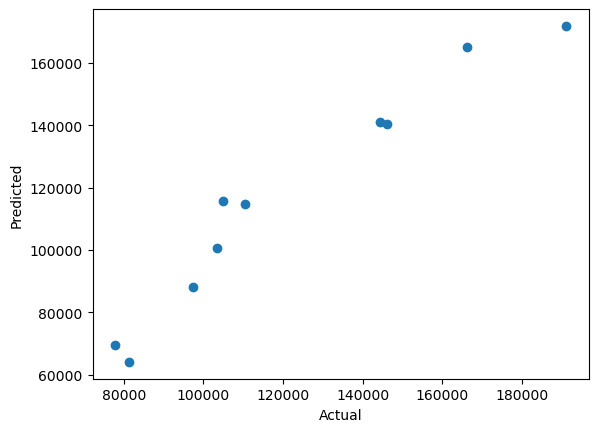

In [12]:
# plot the scatter plot between actual values and predicted values
mtp.scatter(y_test,y_pred);
mtp.xlabel('Actual');
mtp.ylabel('Predicted');

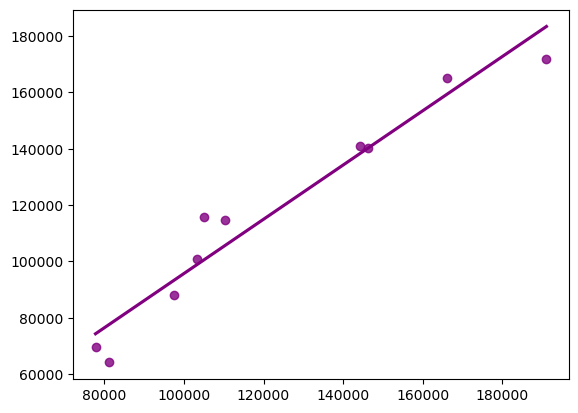

In [15]:
# Regression plot of our model
import seaborn as sns
sns.regplot(x=y_test,y=y_pred,ci=None,color ='purple');

In [14]:
# Predicted Values
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
0,103282.38,100815.651436,2466.728564
1,144259.40,141065.323235,3194.076765
2,146121.95,140351.484257,5770.465743
3,77798.83,69602.813174,8196.016826
4,191050.39,171849.805620,19200.584380
5,105008.31,115796.488399,-10788.178399
6,81229.06,64138.933416,17090.126584
7,97483.56,88177.532847,9306.027153
8,110352.25,114766.471564,-4414.221564
9,166187.94,165080.490740,1107.449260


source https://www.analyticsvidhya.com/blog/2022/03/multiple-linear-regression-using-python/